# Create True Ortho and Digital Surface Model from Drone imagery

## Introduction

This tutorial demonstrates how to automate photogrammetric correction of drone images and generate reality mapping products using the ArcGIS API for Python. You'll learn to create Digital Surface Models (DSM), Digital Terrain Models (DTM), true ortho imagery, and DSM mesh. In this workflow, you will process a collection of nadir drone images through the complete reality mapping pipeline, including:

- Creating a project
- Create a mission
- Perform block adjustment and refine the adjustment using Ground Control Points (GCP)
- Generate true ortho and DSM products

To learn about more about reality mapping concepts, workflows and configurations, see the [Introduction to reality mapping](../guide/introduction-to-reality-mapping) guide.

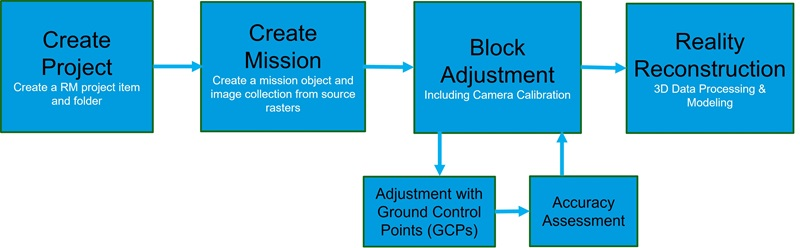

A collection of 195 drone images covering a section of the Esri campus, California, is provided for this tutorial. Each image has embedded EXIF metadata which is used along with the supplied GCP’s to support the block adjustment process.

Download [the tutorial dataset](https://esri-rasterdev.maps.arcgis.com/home/item.html?id=d99cc2563beb4208a3db4e60e9384b43&rsource=https%3A%2F%2Fesriurl.com%2FRealityMappingTutorialData), unzip it, and save contents to your local system, for example `C:\SampleData\RM_Drone_tutorial`.

## Getting Started

Reality mapping capability through ArcGIS API for Python requires ArcGIS Enterprise federated with a Reality Server license. See the [configuration instruction](https://doctopia.esri.com/builds/reality-server/main/en/deploy/configure-arcgis-reality.html) for setup details.

Once your environment is configured, import the required class and module:

- [GIS](/python/latest/api-reference/arcgis.gis.toc.html#gis) class: Represents the organizational deployment and accesses classes to manage content, users, and groups

-  [arcgis.raster.realitymapping](/python/latest/api-reference/arcgis.raster.realitymapping.html) submodule provides the functionality to automate reality mapping tasks in the server environment. The reality mapping module is available with ArcGIS API for Python (version >= 2.4.2)

In [ ]:
from arcgis.gis import GIS
from arcgis.raster import realitymapping

Establish a connection to your ArcGIS Enterprise portal and verify that reality mapping is supported in your environment.

> *note:* Change credentials to match your organization credentials.

In [ ]:
#connect to GIS
gis = GIS(
    url= "https://yourportal.domain.com/portal",
    username= "your username",
    password= "your password"
)

# confirm that reality mapping is supported
realitymapping.is_supported(gis)


## Step 1: Create a Project

The first step is to create a reality mapping project using the [Project](/python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster.realitymapping.Project) class of the reality mapping module. 

In [18]:
# Create a new project
project = realitymapping.Project("DroneProject")
project

<Project - DroneProject>

A project is a top-level workspace for managing reality mapping activities. Initializing a new a project creates a new portal folder and a reality mapping project [item](/python/latest/api-reference/arcgis.gis.toc.html#item) inside that folder. The project item contains the basic information (e.g. project name, group name, workspace name, etc.) that defines a reality mapping project.

In [19]:
# Project item id
project.item.itemid

'ebf8a46d74d54817a0d303cec38ee451'

## Step 2: Create a Mission

The next step is to create a [mission](/python/latest/api-reference/arcgis.raster.realitymapping.html#mission), which contains all related imagery and processed data products for managing a single data capture session. Creating a *mission* creates a supporting image collection for the source rasters. So we need to first define the type, properties and path of the source rasters using the [ImageSource](/python/latest/api-reference/arcgis.raster.toc.html#imagesource) class.

In [ ]:
# Create an image source of UAV type
uav_src = realitymapping.ImageSource("UAV/UAS")
# Define the estimated flying height
uav_src.raster_type.estimate_flight_height = 330
# Define the source rasters' path
uav_src.input_data = r"C:\SampleData\RM_Drone_Tutorial\Images"

Other properties specific to the UAV/UAS image source object we just created can be defined similarly to the *estimate_flight_height* assignment in the cell above. To see the possible attributes, use the [attributes](/python/latest/api-reference/arcgis.raster.toc.html#arcgis.raster.RasterType.attributes) property of the [raster_type](/python/latest/api-reference/arcgis.raster.toc.html#rastertype) instance.

In [48]:
# See other attributes
uav_src.raster_type.attributes

{'name': 'UAV/UAS',
 'camera_info': None,
 'gps_info': None,
 'processing_template': None,
 'dem': None,
 'averagezdem': None,
 'constant_z': None,
 'zfactor': None,
 'zoffset': None,
 'correct_geoid': None,
 'estimate_flight_height': 330,
 'is_altitude_flight_height': None,
 'minimum_flight_height': None,
 'stretch_type': None,
 'scale_factor': None,
 'valid_range': None}

Now we can create the *mission* (and image collection) using the image source object

In [ ]:
mission = project.create_mission(
    image_sources= uav_src,
    out_sr = {"wkid": 32611, "vcsWkid": 5773}
)
mission

195


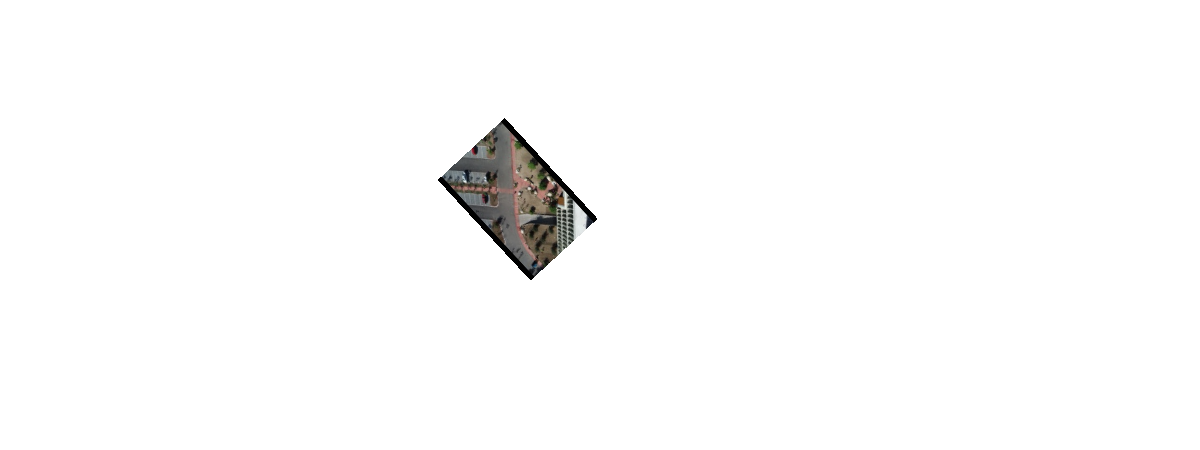

In [52]:
# check the number of images in the image collection
print(mission.image_count)

# Show specifc image in the collection
mission.image_collection.layers[0].filter_by("OBJECTID=69")

At this point, your imagery is organized but not yet geometrically adjusted. The next step is to perform block adjustment.

## Step 3: Perform Adjustment

`Block adjustment` involves using tie points to calculate the exterior orientation for each each image such that they are consistent with neighboring images (Relative orientation). A more refined adjustment can then be performed using Ground Control Points (GCP). [Read more about adjustment here.](https://www.esri.com/arcgis-blog/products/arcgis-pro/imagery/ortho-mapping-arcgis-block-adjustment/)

### 3.1 Compute Initial Block Adjustment

To perform block adjustment, we call the [compute_sensor_model()](/python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster._realitymapping_mission.Mission.compute_sensor_model) method of the mission object. The *compute_sensor_model()* method  computes block adjustment for the image collection and applies the frame transform to the images based on the raster type information used when creating the image collection. It also generates the control points feature class, solution table, solution points feature class, and flight path feature class. 

> *note:* These feature classes and tables will be saved in raster store and will not be created in the ArcGIS Enterprise as separate items.

For preliminary quality purposes, we can perform block adjustment at quick or full mode. Quick mode computes tie points and adjustment at 8x of the source imagery resolution while full mode adjust the images in Quick mode then at 1x of the source imagery resolution. Running under either of these two modes will make it ready for another block adjustment run with more ground control points and matching tie points later on.

In [ ]:
mission.compute_sensor_model(mode="Full", location_accuracy="High")

The adjustment report contain information about the quality of bundle block adjustment 

In [ ]:
mission.generate_report(report_format= "HTML")

Confirm that everything looks goods for the quality check of the adjustment report, except for the warning that Ground Control Points and Check Points are not used in the adjustment. 

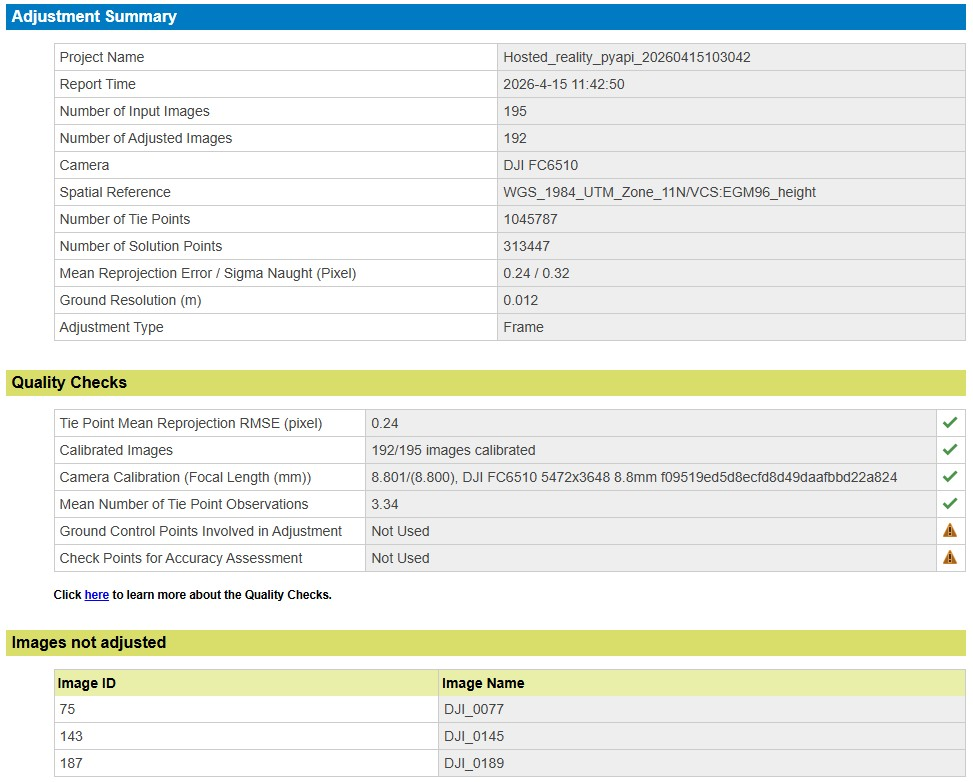

### 3.2 Add ground control points (optional)

The reality mapping workflow may need to run adjustment twice. The initial block adjustment is computed to generate the tie points among overlapping images for preliminary results. The second block adjustment is computed with ground control points for refined results. Note that this step is optional.

The workflow for adding GCP involves:

1. Prepare input control points for the data : The first step is to define the ground control points. This will be a list of GCPs (see figure below) and for each gcp in the list, a tie point on at least one image needs to be specified.   
2. Match control points : Next, we will use [match_control_points](/python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster._realitymapping_mission.Mission.match_control_points) to find matching tie points on other overlapping images. 
3. Update the control points feature class : Then, we will run [edit_control_points](/python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster._realitymapping_mission.Mission.edit_control_points) to update the control point feature class.

#### 3.2.1 Prepare the GCP

The location information of the control points for this tutorial data is shown in the picture below.

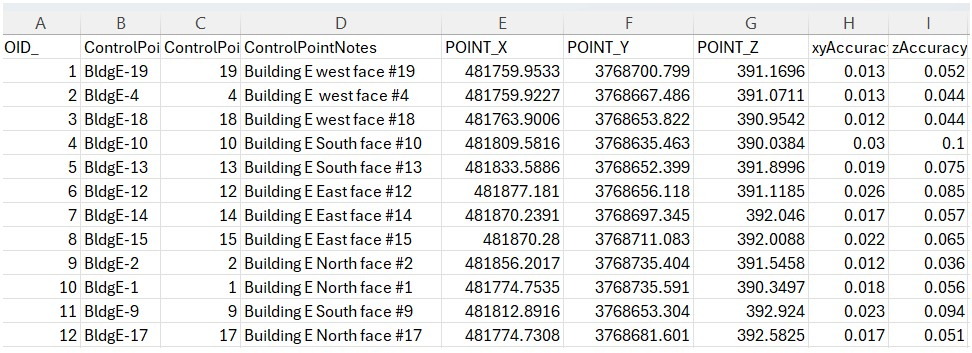

The first GCP ("x": 481759.9533, "y": 3768700.799,"z": 391.1696) appears in a couple of images including DJI_0071.JPG image whose image ID in the image collection is 69. Open this image with paint or other photo editor and confirm that the image coordinate of the control point marker is 4108, -2929.  Note that the column value is negative because the reference for the image coordinate system is top-up.

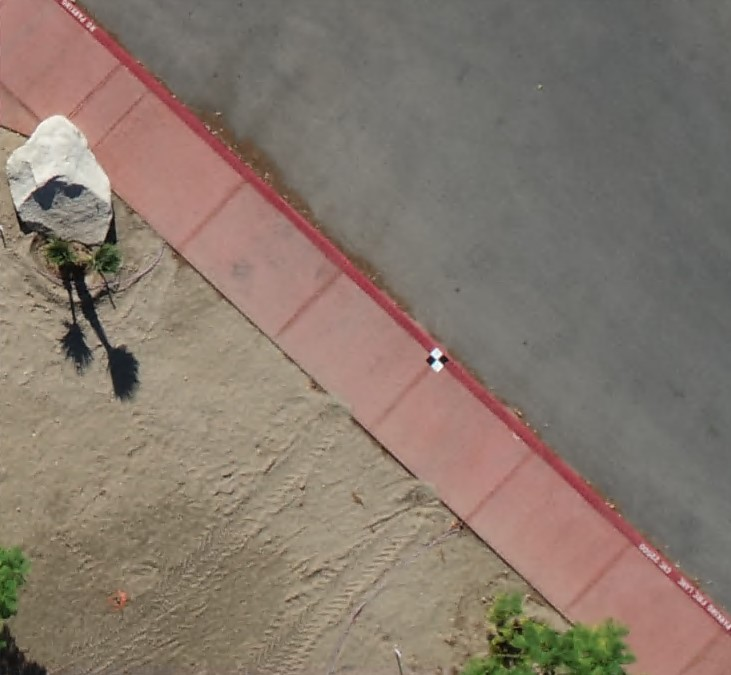


After determining the location and tie points of other control points in similar approach, the input control points variable is defined below. 

To use some of the control points as check point, specify the type as 3.

In [ ]:
input_gcp = [
    {
         "pointId": 1,"x": 481759.9533, "y": 3768700.799,"z": 391.1696,
         "spatialReference": {"wkid":26911, "vcsWkid": 5773},
         "xyAccuracy": 0.013,"zAccuracy": 0.052,
         "imagePoints": [
             {
              "imageID": 69,
              "u": 4108,]
              "v": -2929
             }
         ] 
    },
    {
        "pointId": 2, "gcptype": 3, "x": 481759.9227, "y": 3768667.486,"z": 391.0711,
         "spatialReference": {"wkid":26911, "vcsWkid": 5773},
         "xyAccuracy": 0.013,"zAccuracy": 0.044,
         "imagePoints": [
             {
              "imageID": 69,
              "u": 2135,
              "v": -1086
             }
          ] 
    },
    {
        "pointId": 3, "x": 481763.9006, "y": 3768653.822,"z": 390.9542,
        "spatialReference": {"wkid":26911, "vcsWkid": 5773},
        "xyAccuracy": 0.012,"zAccuracy": 0.044,
        "imagePoints": [
            {
             "imageID": 51,
             "u": 2598,
             "v": -3113
            }
         ] 
    },
    {
        "pointId": 4,"x": 481809.5816, "y": 3768635.463,"z": 390.0384,
        "spatialReference": {"wkid":26911, "vcsWkid": 5773},
        "xyAccuracy": 0.03,"zAccuracy": 0.1,
        "imagePoints": [
            {
             "imageID": 36,
             "u": 1366,
             "v": -2462
            }
        ] 
    },
    {
        "pointId": 5,"x": 481833.5886, "y": 3768652.399,"z": 391.8996,
        "spatialReference": {"wkid":26911, "vcsWkid": 5773},
        "xyAccuracy": 0.019,"zAccuracy": 0.075,
        "imagePoints": [
            {
             "imageID": 15,
             "u": 2664,
             "v": -2159
            }
        ] 
     },
     {
         "pointId": 6,"x": 481877.181, "y": 3768656.118,"z": 391.1185,
         "spatialReference": {"wkid":26911, "vcsWkid": 5773},
         "xyAccuracy": 0.026,"zAccuracy": 0.085,
         "imagePoints": [
             {
              "imageID": 8,
              "u": 2518,
              "v": -3162
             }
         ] 
     },
     {
         "pointId": 7, "gcptype": 3, "x": 481870.2391, "y": 3768697.345,"z": 392.046,
         "spatialReference": {"wkid":26911, "vcsWkid": 5773},
         "xyAccuracy": 0.017,"zAccuracy": 0.057,
         "imagePoints": [
             {
              "imageID": 28,
              "u": 1360,
              "v": -724
             }
         ] 
     },
     {
         "pointId": 8,"x": 481870.28, "y": 3768711.083,"z": 392.0088,
         "spatialReference": {"wkid":26911, "vcsWkid": 5773},
         "xyAccuracy": 0.022,"zAccuracy": 0.065,
         "imagePoints": [
             {
              "imageID": 28,
              "u": 2170,
              "v": -1490
             }
         ] 
     },
     {
         "pointId": 9,"x": 481856.2017, "y": 3768735.404,"z": 391.5458,
         "spatialReference": {"wkid":26911, "vcsWkid": 5773},
         "xyAccuracy": 0.012,"zAccuracy": 0.036,
         "imagePoints": [
             {
              "imageID": 58,
              "u": 3152,
              "v": -871
             }
         ] 
     },
     {
         "pointId": 11, "gcptype": 3, "x": 481812.8916, "y": 3768653.304,"z": 392.924,
         "spatialReference": {"wkid":26911, "vcsWkid": 5773},
         "xyAccuracy": 0.023,"zAccuracy": 0.094,
         "imagePoints": [
             {
              "imageID": 35,
              "u": 2132,
              "v": -2613
             }
         ] 
     },
     {
         "pointId": 12,"x": 481774.7308, "y": 3768681.601,"z": 392.5825,
         "spatialReference": {"wkid":26911, "vcsWkid": 5773},
         "xyAccuracy": 0.017,"zAccuracy": 0.051,
         "imagePoints": [
             {
              "imageID": 68,
              "u": 2081,
              "v": -1625
             }
         ] 
     }
]

#### 3.2.2 Match Control Points

We have created a GCP with atleast one tie point but each tie point needs to be identified in other overlapping images. Manually creating tie points for all overlapping images is labor intensive. For a given ground control point and initial tie point in one of the overlapping images, [match_control_points()](/python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster._realitymapping_mission.Mission.match_control_points) will help find all remaining tie points on all other image items of the image collection.

In [62]:
control_point_sets = mission.match_control_points(
                        control_points=input_gcp, 
                        similarity="High"
                    )

In [63]:
control_point_sets

[{'pointID': 1,
  'x': 481759.95329979766,
  'y': 3768700.7990001333,
  'z': 391.1695999999938,
  'spatialReference': {'wkid': 26911,
   'latestWkid': 26911,
   'vcsWkid': 5773,
   'latestVcsWkid': 5773},
  'xyAccuracy': 0.013,
  'ZAccuracy': 0.052,
  'imagePointSpatialReference': {'ics': '', 'topup': True},
  'imagePoints': [{'imageID': 69,
    'x': 3076.754447380615,
    'y': -3552.4940620410443,
    'u': 4108,
    'v': -2929,
    'score': -1},
   {'imageID': 67,
    'x': 4412.319591530715,
    'y': -1672.551351078611,
    'u': 3991.1201923668373,
    'v': -701.9304084823648,
    'score': 0.99},
   {'imageID': 68,
    'x': 3773.268635764324,
    'y': -2637.8794522488297,
    'u': 4054.6087874864675,
    'v': -1812.1916272282103,
    'score': 0.99},
   {'imageID': 79,
    'x': 4444.966258914339,
    'y': -2492.7150899575186,
    'u': 3590.8421693692017,
    'v': -199.15384796311332,
    'score': 0.99},
   {'imageID': 80,
    'x': 3365.584176242943,
    'y': -2571.775692821053,
    'u'

#### 3.2.3 Update Control Points Feature Class

Next, we will append the control point sets to the image collection’s control point feature class using [edit_control_points()](/python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster._realitymapping_mission.Mission.edit_control_points).

In [ ]:
mission.edit_control_points(control_points= control_point_sets)

### 3.3 Redo Block Adjustment

After adding the ground control point sets to the image collection's control point table with steps above, we can rerun compute sensor model to refine block adjustment result.

Here, `mode='Refine'` represents to adjust the image at 1x of the source imagery resolution.

In [ ]:
mission.compute_sensor_model(
                mode="Refine", 
                location_accuracy="High"
)

In [ ]:
mission.generate_report(report_format="HTML")

## Step 4: Get Results

The final step after block adjustment is to generate products. The [reconstruct_surface()](/python/latest/api-reference/arcgis.raster.realitymapping.html#arcgis.raster._realitymapping_mission.Mission.reconstruct_surface) method can generate one or multiple reality mapping products- DSM, DTM, true ortho, DSM Mesh, 3D meshes, and point clouds from adjusted imagery.

In [ ]:
%%time
products_2d = mission.reconstruct_surface(
                        scenario= "Drone",
                        quality= "High",
                        output_dsm_name= "DroneDSM",
                        output_dtm_name= "DroneDTM",
                        output_true_ortho_name= "DroneTrueOrtho"
             )

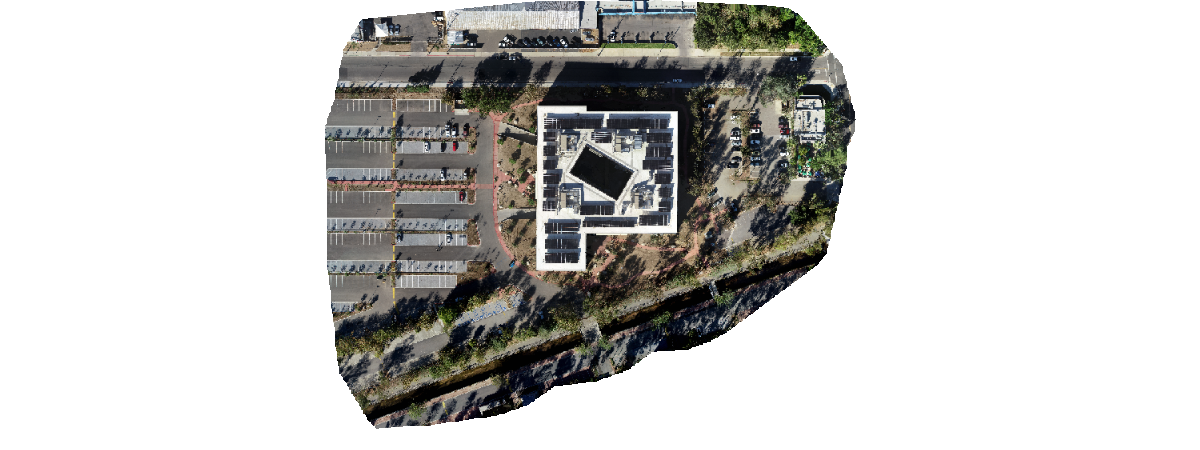

In [21]:
products_2d.True_Ortho.layers[0]

## Conclusion

You've successfully completed a reality mapping workflow for drone imagery using the ArcGIS API for Python. In this tutorial, you:

- Created a reality mapping project and mission for drone imagery.
- Performed block adjustment to geometrically correct your imagery collection.
- Refined the adjustment using GCPs for improved absolute accuracy.
- Generated DSM, DTM and true ortho products.

The same principles and methods demonstrated here can be adapted for:
* [satellite](../guide/create-trueortho-dsm-from-satellite-imagery)
* [nadir](../guide/create-2D-digital-aerial-products)
* [oblique digital aerial imagery processing](../guide/create-3D-digital-aerial-products)

This is a versatile approach for reality mapping across different platforms and scales.